Project Two: North Carolina Housing Prices

Research question: How will housing market prices in North Carolina change in the next year?




In [1]:
import os
import numpy as np 
import pandas as pd 
import requests 
import matplotlib.pyplot as plt 
import seaborn as sns 
import statsmodels.api as sm 

from dotenv import load_dotenv 
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error 
from sklearn.impute import SimpleImputer 
from sklearn.pipeline import Pipeline 
# Import all nessesary libaries

In [2]:
load_dotenv() # loads variables from the .env file

API_KEY = os.getenv("CENSUS_API_KEY") # gets the census api key

folder = r"C:\Users\Savio\OneDrive\Desktop\DS2\project 2" # sets the project folder

print("Setup complete.")

Setup complete.


Census data: population, housing units, and income


In [3]:
years = list(range(2005, 2020)) + list(range(2021, 2025)) # creates or updates this value

census_data = [] # creates an empty list

for year in years: # loops through each year
    url = (f"https://api.census.gov/data/{year}/acs/acs1"f"?get=NAME,B01001_001E,B25001_001E,B19013_001E"f"&for=state:37&key={API_KEY}") # creates or updates this value

    response = requests.get(url) # sends a GET request
    response.raise_for_status() # checks for a request error

    data = response.json() # converts the response to python data
    row = dict(zip(data[0], data[1])) # pairs the values together

    census_data.append({ # adds the item to the list
        "Year": year, 
        "Population": int(row["B01001_001E"]), 
        "Housing_Units": int(row["B25001_001E"]), 
        "Median_Household_Income": int(row["B19013_001E"])}) 

census_df = pd.DataFrame(census_data) # creates or updates this value

print(census_df) 
print("Shape:", census_df.shape) 

    Year  Population  Housing_Units  Median_Household_Income
0   2005     8411041        3940554                    40729
1   2006     8856505        4026558                    42625
2   2007     9061032        4124066                    44670
3   2008     9222414        4200447                    46549
4   2009     9380884        4258573                    43674
5   2010     9561558        4333479                    43326
6   2011     9656401        4362956                    43916
7   2012     9752073        4375400                    45150
8   2013     9848060        4394515                    45906
9   2014     9943964        4452464                    46556
10  2015    10042802        4491090                    47830
11  2016    10146788        4540697                    50584
12  2017    10273419        4622656                    52752
13  2018    10383620        4684962                    53855
14  2019    10488084        4748148                    57341
15  2021    10551162    

Zillow ZHVI data

In [4]:
zillow_raw = pd.read_csv(folder + r"\State_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv") # reads the data file

# North Carolina only
zillow_nc = zillow_raw[zillow_raw["RegionName"] == "North Carolina"].copy() # makes a copy of the data

# Historical ZHVI: January 2005 through December 2024
date_columns = pd.date_range(start = "2005-01-31", end = "2024-12-31", freq = "ME").strftime("%Y-%m-%d").tolist() # creates the date range

zillow_nc = zillow_nc[["RegionName"] + date_columns].melt(id_vars = "RegionName", var_name = "Month", value_name = "ZHVI") # changes the data to long format

zillow_nc["Month"] = pd.to_datetime(zillow_nc["Month"]).dt.to_period("M") # converts the date to datetime

zillow_nc["Year"] = zillow_nc["Month"].dt.year # creates or updates this value

zillow_nc = zillow_nc.drop(columns="RegionName") # removes columns or rows

print(zillow_nc.head())
print(zillow_nc.tail())
print("Shape:", zillow_nc.shape)

     Month           ZHVI  Year
0  2005-01  150895.232463  2005
1  2005-02  151318.912214  2005
2  2005-03  151715.846084  2005
3  2005-04  152242.578927  2005
4  2005-05  152804.337813  2005
       Month           ZHVI  Year
235  2024-08  337637.705627  2024
236  2024-09  337521.928506  2024
237  2024-10  337539.608817  2024
238  2024-11  337512.950650  2024
239  2024-12  337944.921545  2024
Shape: (240, 3)


Mortgage rates data

In [5]:
mortgage_df = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US") # reads the data file

mortgage_df["observation_date"] = pd.to_datetime(mortgage_df["observation_date"]) # converts the date to datetime

mortgage_df = mortgage_df[(mortgage_df["observation_date"].dt.year >= 2005) & (mortgage_df["observation_date"].dt.year <= 2024)].copy() # makes a copy of the data

mortgage_df["Month"] = mortgage_df["observation_date"].dt.to_period("M") # converts dates to months

mortgage_monthly = (mortgage_df.groupby("Month")["MORTGAGE30US"].mean().reset_index().rename(columns={"MORTGAGE30US": "Mortgage_Rate"})) # groups the data

print(mortgage_monthly.head()) 
print(mortgage_monthly.tail()) 
print("Shape:", mortgage_monthly.shape) 

     Month  Mortgage_Rate
0  2005-01         5.7100
1  2005-02         5.6275
2  2005-03         5.9280
3  2005-04         5.8550
4  2005-05         5.7200
       Month  Mortgage_Rate
235  2024-08          6.500
236  2024-09          6.180
237  2024-10          6.428
238  2024-11          6.805
239  2024-12          6.715
Shape: (240, 2)


Building permits data

In [6]:
permit_rows = [] # creates an empty list

for year in range(2005, 2025): # loops through the years
    url = f"https://www2.census.gov/econ/bps/State/st{year}a.txt" # creates census url for building permits data

    permit_df = pd.read_csv(url, skiprows = 2, header = None) # reads the data file

    nc_row = permit_df[permit_df.iloc[:, 4].astype(str).str.strip() == "North Carolina"] # finds north carolina row in the data

    if nc_row.empty: # checks if nc was found in the data
        raise ValueError(f"North Carolina not found in building permits file for {year}.") # stop with error if nc not found

    row = nc_row.iloc[0] # creates nc row

    # Units columns for 1-unit, 2-unit, 3-4-unit, and 5+ unit categories
    permit_units = sum(pd.to_numeric(row.iloc[i], errors = "coerce") for i in [6, 9, 12, 15]) # converts values to numbers

    permit_rows.append({"Year": year, "Building_Permits": int(permit_units)}) # adds the item to the list

building_permits = pd.DataFrame(permit_rows) # creates dataframe
print(building_permits) 
print("Shape:", building_permits.shape) 

    Year  Building_Permits
0   2005             97910
1   2006             99979
2   2007             85777
3   2008             54652
4   2009             33800
5   2010             33889
6   2011             32804
7   2012             48692
8   2013             51290
9   2014             49911
10  2015             54757
11  2016             60550
12  2017             67047
13  2018             71691
14  2019             71307
15  2020             80474
16  2021             94874
17  2022             94118
18  2023             98853
19  2024             95163
Shape: (20, 2)


In [7]:
# Start with Zillow
housing_df = zillow_nc.copy() # makes a copy of the data

# Add annual Census variables
housing_df = housing_df.merge(census_df, on = "Year", how = "left") # merges the datasets

# Add monthly mortgage rates
housing_df = housing_df.merge(mortgage_monthly, on = "Month", how = "left") # merges the datasets


# Add annual building permits
housing_df = housing_df.merge(building_permits, on = "Year", how = "left") # merges the datasets

# 2020 is intentionally excluded because the Census 1-year variables are unavailable.
housing_df = housing_df[housing_df["Year"] != 2020].copy() # makes a copy of the data

housing_df = housing_df.sort_values("Month").reset_index(drop = True) # sorts the data

print(housing_df.head()) 
print(housing_df.tail())
print("Shape:", housing_df.shape) 
print("\nMissing values:") 
print(housing_df.isna().sum()) 

     Month           ZHVI  Year  Population  Housing_Units  \
0  2005-01  150895.232463  2005   8411041.0      3940554.0   
1  2005-02  151318.912214  2005   8411041.0      3940554.0   
2  2005-03  151715.846084  2005   8411041.0      3940554.0   
3  2005-04  152242.578927  2005   8411041.0      3940554.0   
4  2005-05  152804.337813  2005   8411041.0      3940554.0   

   Median_Household_Income  Mortgage_Rate  Building_Permits  
0                  40729.0         5.7100             97910  
1                  40729.0         5.6275             97910  
2                  40729.0         5.9280             97910  
3                  40729.0         5.8550             97910  
4                  40729.0         5.7200             97910  
       Month           ZHVI  Year  Population  Housing_Units  \
223  2024-08  337637.705627  2024  11046024.0      5073509.0   
224  2024-09  337521.928506  2024  11046024.0      5073509.0   
225  2024-10  337539.608817  2024  11046024.0      5073509.0   

clean data

In [8]:
long_features = [ 
    "Population", 
    "Housing_Units", 
    "Median_Household_Income", 
    "Mortgage_Rate", 
    "Building_Permits"] 

print(housing_df.columns.tolist())
print("\nRows:", len(housing_df)) 
print("Years:", housing_df["Year"].unique()) 


['Month', 'ZHVI', 'Year', 'Population', 'Housing_Units', 'Median_Household_Income', 'Mortgage_Rate', 'Building_Permits']

Rows: 228
Years: [2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018
 2019 2021 2022 2023 2024]


In [9]:
pd.set_option("display.max_rows", None) 
pd.set_option("display.max_columns", None) 
pd.set_option("display.width", None) 

display(housing_df)
# Shows whole table

,Month,ZHVI,Year,Population,Housing_Units,Median_Household_Income,Mortgage_Rate,Building_Permits
0,2005-01,150895.232463,2005,8411041.0,3940554.0,40729.0,5.7100,97910
1,2005-02,151318.912214,2005,8411041.0,3940554.0,40729.0,5.6275,97910
2,2005-03,151715.846084,2005,8411041.0,3940554.0,40729.0,5.9280,97910
3,2005-04,152242.578927,2005,8411041.0,3940554.0,40729.0,5.8550,97910
4,2005-05,152804.337813,2005,8411041.0,3940554.0,40729.0,5.7200,97910
5,2005-06,153493.635892,2005,8411041.0,3940554.0,40729.0,5.5820,97910
6,2005-07,154256.170849,2005,8411041.0,3940554.0,40729.0,5.6950,97910
7,2005-08,155089.260870,2005,8411041.0,3940554.0,40729.0,5.8200,97910
8,2005-09,155904.051541,2005,8411041.0,3940554.0,40729.0,5.7740,97910
9,2005-10,156758.276795,2005,8411041.0,3940554.0,40729.0,6.0650,97910


visualizations

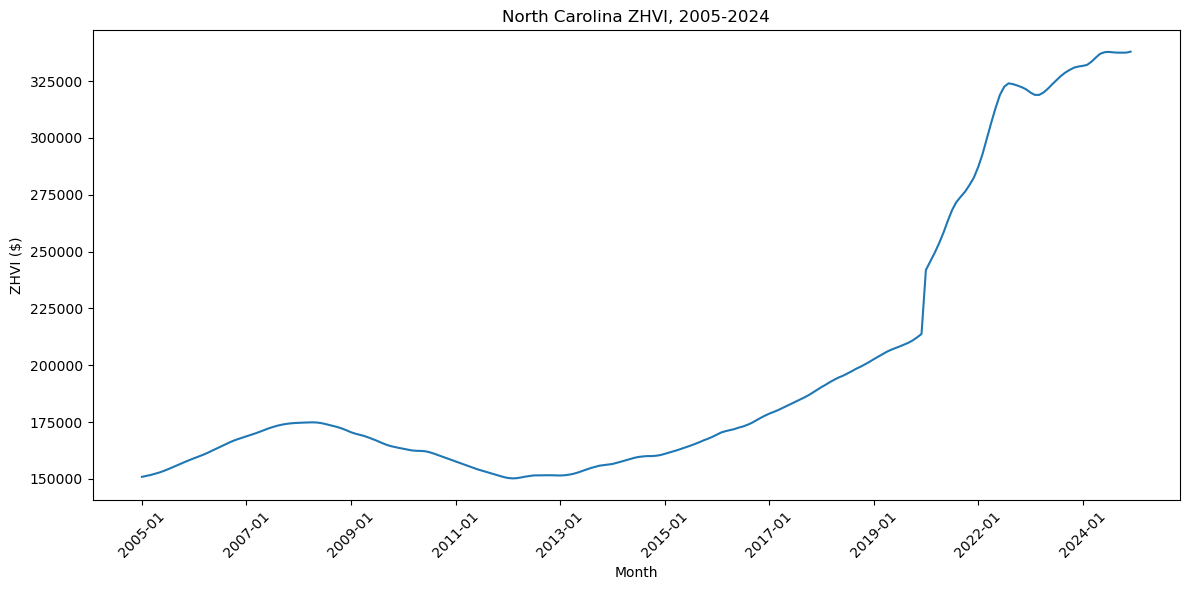

In [10]:
# ZHVI over time
plt.figure(figsize = (12, 6)) 
plt.plot(housing_df["Month"].astype(str), housing_df["ZHVI"]) 
plt.xlabel("Month") 
plt.ylabel("ZHVI ($)") 
plt.title("North Carolina ZHVI, 2005-2024") 

step = 24 
positions = np.arange(0, len(housing_df), step) 
plt.xticks(positions, housing_df["Month"].astype(str).iloc[positions], rotation = 45) 

plt.tight_layout() 
plt.show() 
# Creates a time trend of ZHVI over time

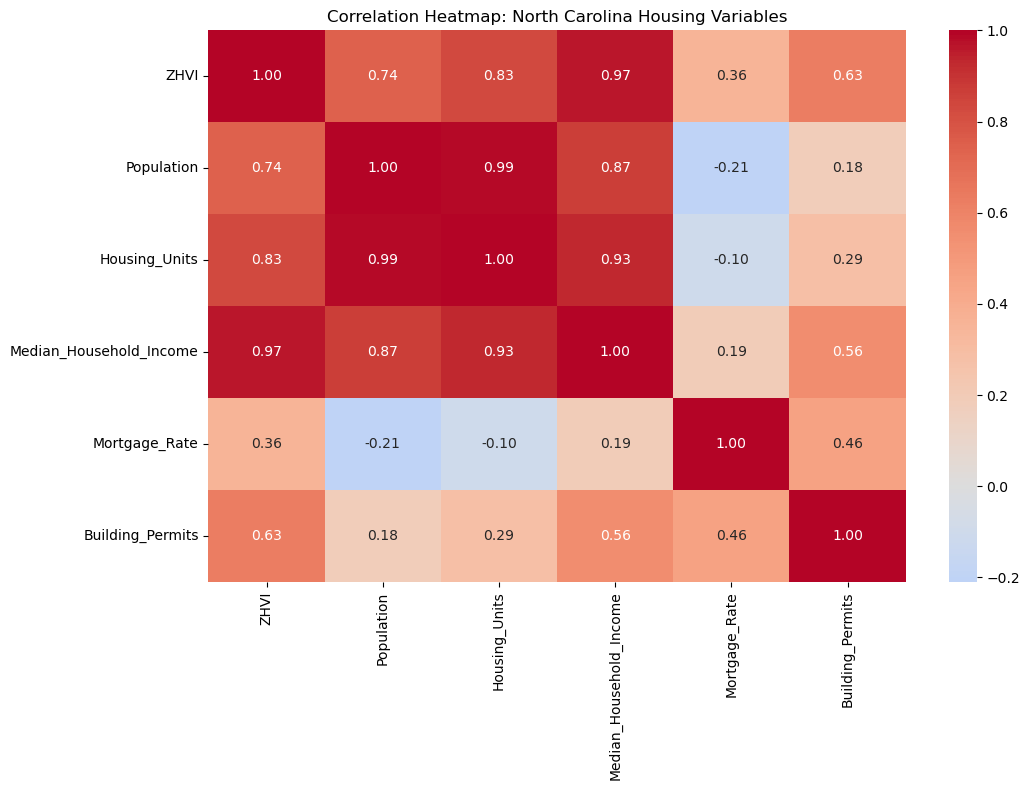

In [11]:
correlation_data = housing_df[["ZHVI"] + long_features].copy()

correlation_matrix = correlation_data.corr() 

plt.figure(figsize = (11, 8))
sns.heatmap(correlation_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", center = 0)
plt.title("Correlation Heatmap: North Carolina Housing Variables")
plt.tight_layout()
plt.show()
#Creates a heatmap for every variable in the dataset

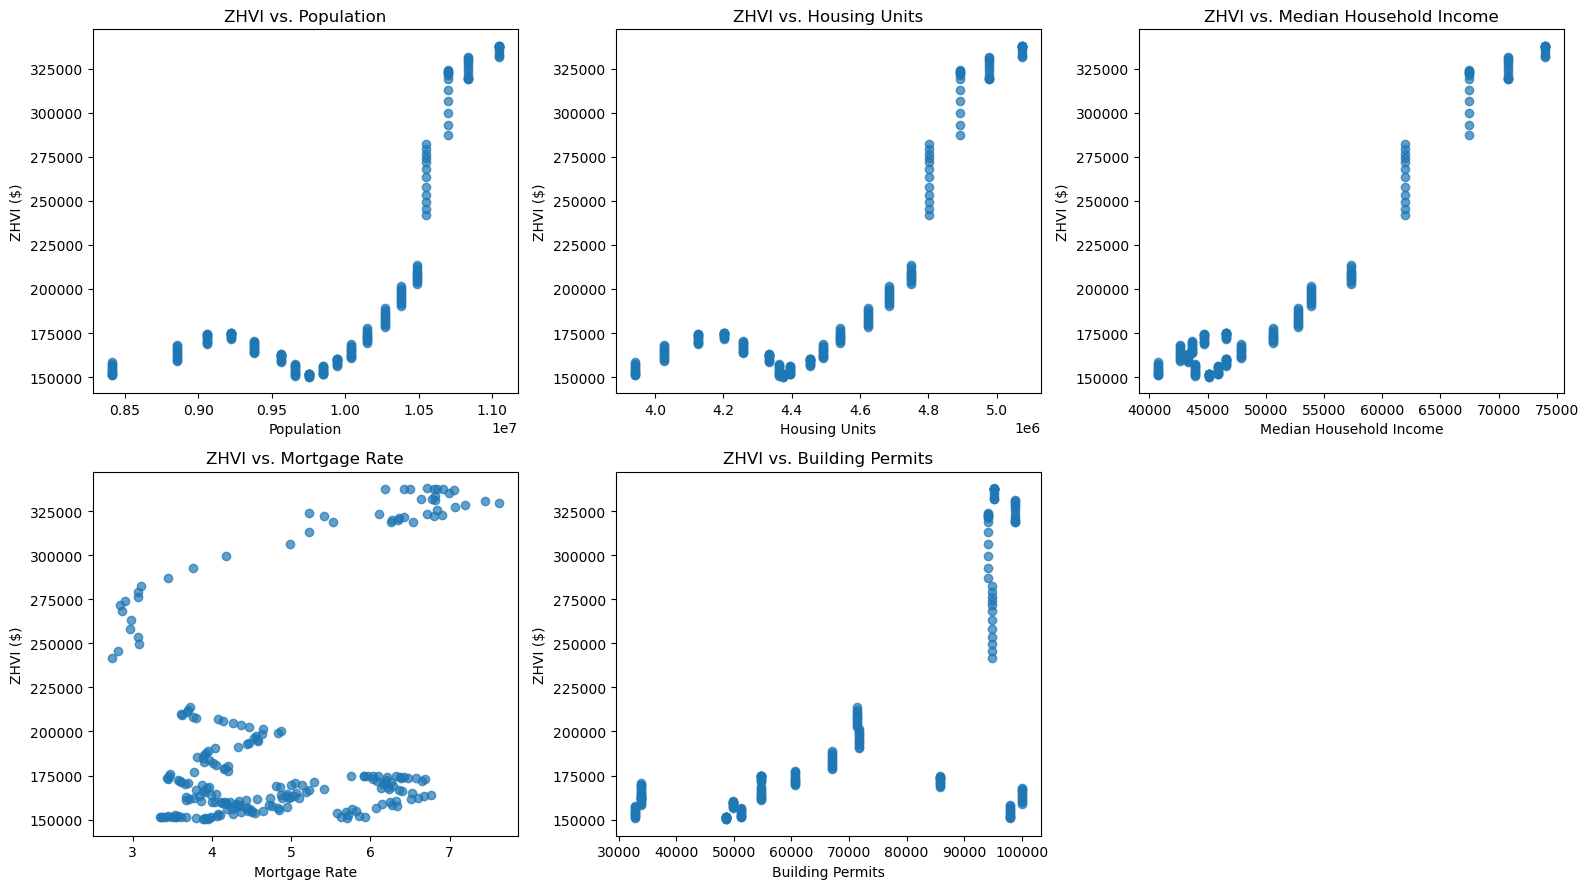

In [12]:

fig, axes = plt.subplots(2, 3, figsize = (16, 9)) 

for ax, feature in zip(axes.flat, long_features):
    ax.scatter(housing_df[feature], housing_df["ZHVI"], alpha = 0.7) 
    ax.set_xlabel(feature.replace("_", " "))
    ax.set_ylabel("ZHVI ($)")
    ax.set_title(f"ZHVI vs. {feature.replace('_', ' ')}")

axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()
# Creates a scatter plot for every variable in the dataset vs ZHVI

New added variables starting at 2019

In [13]:
redfin_raw = pd.read_csv(folder + r"\redfin_housing_market_monthly_all_states_key_metrics_2019_Jan_to_2024_Dec.csv") # reads the Redfin data

redfin_nc = redfin_raw[redfin_raw["REGION NAME"] == "North Carolina"].copy() # makes a copy of only nc data

redfin_nc = redfin_nc[["PERIOD BEGIN", "HOMES SOLD", "NEW LISTINGS", "ACTIVE LISTINGS"]].copy() # makes a copy of the data that is needed from nc

redfin_nc["Month"] = pd.to_datetime(redfin_nc["PERIOD BEGIN"]).dt.to_period("M") # converts the date to datetime

redfin_nc = redfin_nc.rename(columns = {"HOMES SOLD": "Homes_Sold", "NEW LISTINGS": "New_Listings", "ACTIVE LISTINGS": "Active_Listings"}) # renames the columns

redfin_nc = redfin_nc[["Month", "Homes_Sold", "New_Listings", "Active_Listings"]].sort_values("Month") # sorts the data

recent_market_df = housing_df.merge(redfin_nc, on = "Month", how = "inner") # merges the datasets

print(recent_market_df.head()) 
print(recent_market_df.tail()) 
print("Shape:", recent_market_df.shape)
# Adds the data to the dataset

     Month           ZHVI  Year  Population  Housing_Units  \
0  2019-01  202616.707123  2019  10488084.0      4748148.0   
1  2019-02  203722.946072  2019  10488084.0      4748148.0   
2  2019-03  204861.610758  2019  10488084.0      4748148.0   
3  2019-04  205892.513495  2019  10488084.0      4748148.0   
4  2019-05  206788.186262  2019  10488084.0      4748148.0   

   Median_Household_Income  Mortgage_Rate  Building_Permits  Homes_Sold  \
0                  57341.0         4.4640             71307     12667.0   
1                  57341.0         4.3700             71307     13273.0   
2                  57341.0         4.2650             71307     13169.0   
3                  57341.0         4.1425             71307     13156.0   
4                  57341.0         4.0720             71307     13421.0   

   New_Listings  Active_Listings  
0       14845.0          63943.0  
1       14571.0          63923.0  
2       14955.0          63959.0  
3       15632.0          64394.0  
4

In [14]:
# List the recent variables used in the OLS model
recent_features = long_features + ["Homes_Sold", "New_Listings", "Active_Listings"]

# Create the OLS dataset using the recent variables
ols_data = recent_market_df[["ZHVI"] + recent_features].dropna().copy()

# Set the predictor variables
X_ols = ols_data[recent_features]

# Add a constant for the intercept
X_ols = sm.add_constant(X_ols)

# Set ZHVI as the dependent variable
y_ols = ols_data["ZHVI"]

# Create and fit the OLS model
ols_model = sm.OLS(y_ols, X_ols).fit()

# Display the OLS results
print(ols_model.summary())
# Tests how the recent variables are related to ZHVI


                            OLS Regression Results                            
Dep. Variable:                   ZHVI   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     358.7
Date:                Sun, 04 Oct 2026   Prob (F-statistic):           4.90e-42
Time:                        11:37:11   Log-Likelihood:                -610.77
No. Observations:                  60   AIC:                             1240.
Df Residuals:                      51   BIC:                             1258.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    1

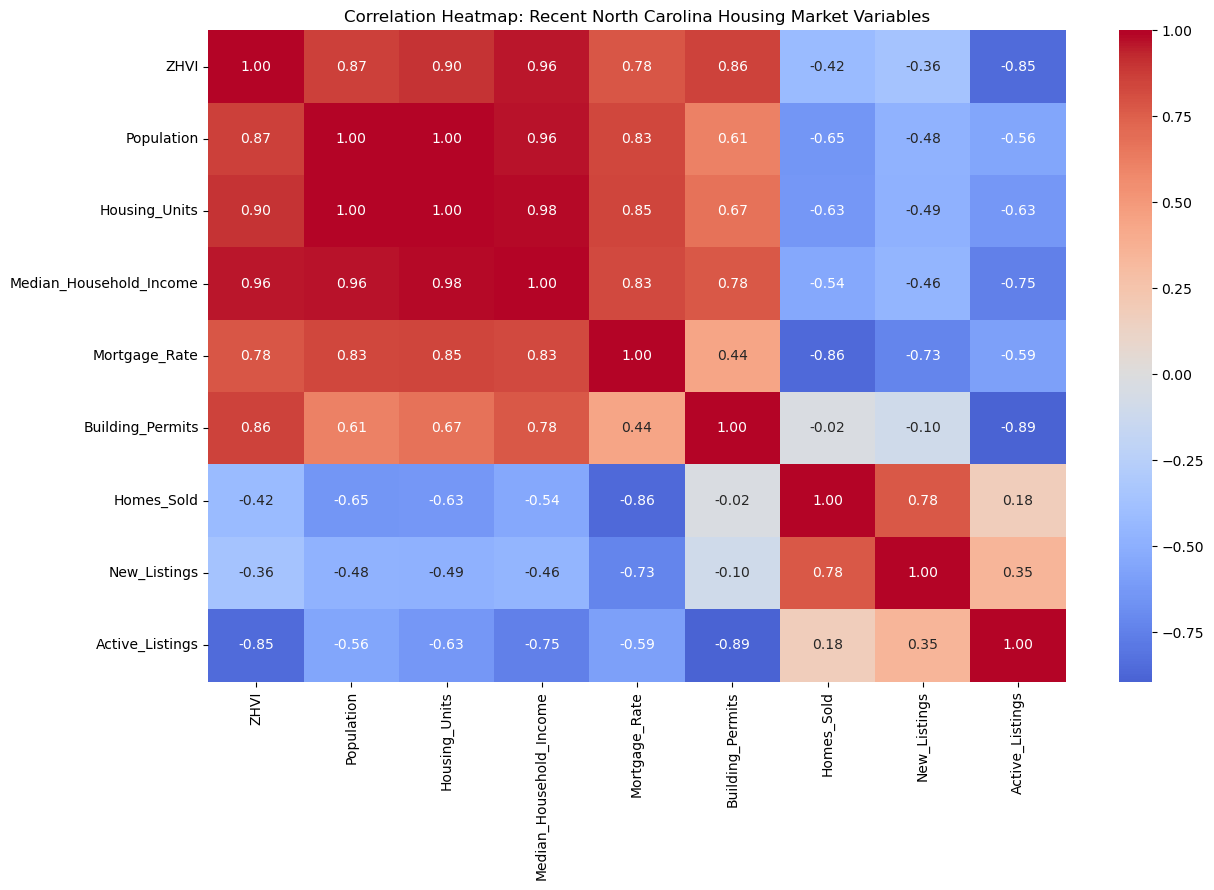

In [15]:
recent_correlation = recent_market_df[["ZHVI"] + recent_features].corr() 

plt.figure(figsize = (13, 9)) 
sns.heatmap(recent_correlation, annot = True, fmt = ".2f", cmap = "coolwarm", center = 0) 
plt.title("Correlation Heatmap: Recent North Carolina Housing Market Variables") 
plt.tight_layout() 
plt.savefig("recent_correlation_heatmap.png", dpi = 300, bbox_inches = "tight")
plt.show() 
# Creactes recent-market correlation heatmap with added variables

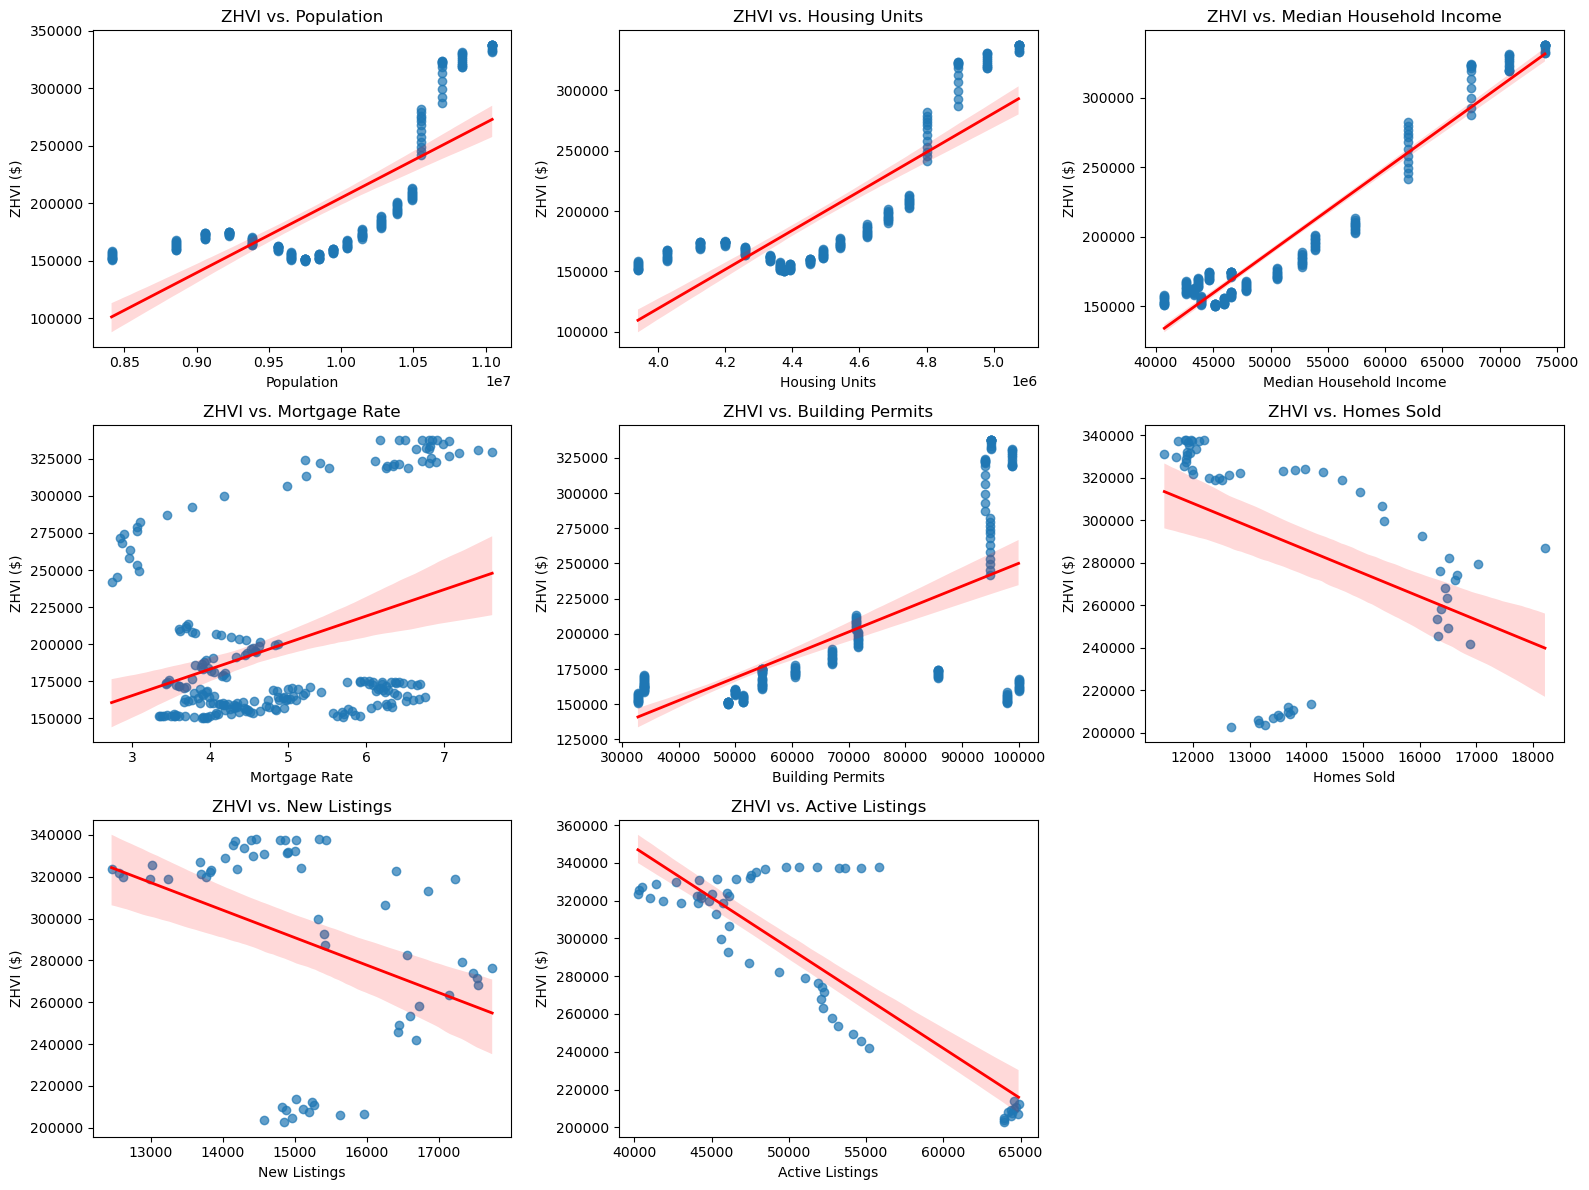

In [16]:
fig, axes = plt.subplots(3, 3, figsize = (16, 12))

# Original variables from housing_df
for ax, feature in zip(axes.flat, long_features):
    sns.regplot(
        x = housing_df[feature],
        y = housing_df["ZHVI"],
        ax = ax,
        scatter_kws = {"alpha": 0.7},
        line_kws = {"color": "red", "linewidth": 2})

    ax.set_xlabel(feature.replace("_", " "))
    ax.set_ylabel("ZHVI ($)")
    ax.set_title(f"ZHVI vs. {feature.replace('_', ' ')}")


# Redfin variables from recent_market_df
redfin_features = ["Homes_Sold", "New_Listings", "Active_Listings"]

for ax, feature in zip(axes.flat[len(long_features):], redfin_features):
    sns.regplot(
        x = recent_market_df[feature],
        y = recent_market_df["ZHVI"],
        ax = ax,
        scatter_kws = {"alpha": 0.7},
        line_kws = {"color": "red", "linewidth": 2})

    ax.set_xlabel(feature.replace("_", " "))
    ax.set_ylabel("ZHVI ($)")
    ax.set_title(f"ZHVI vs. {feature.replace('_', ' ')}")


# Hide unused plots
for ax in axes.flat[len(long_features) + len(redfin_features):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("ZHVI_regression_relationships.png", dpi = 300, bbox_inches = "tight")
plt.show()

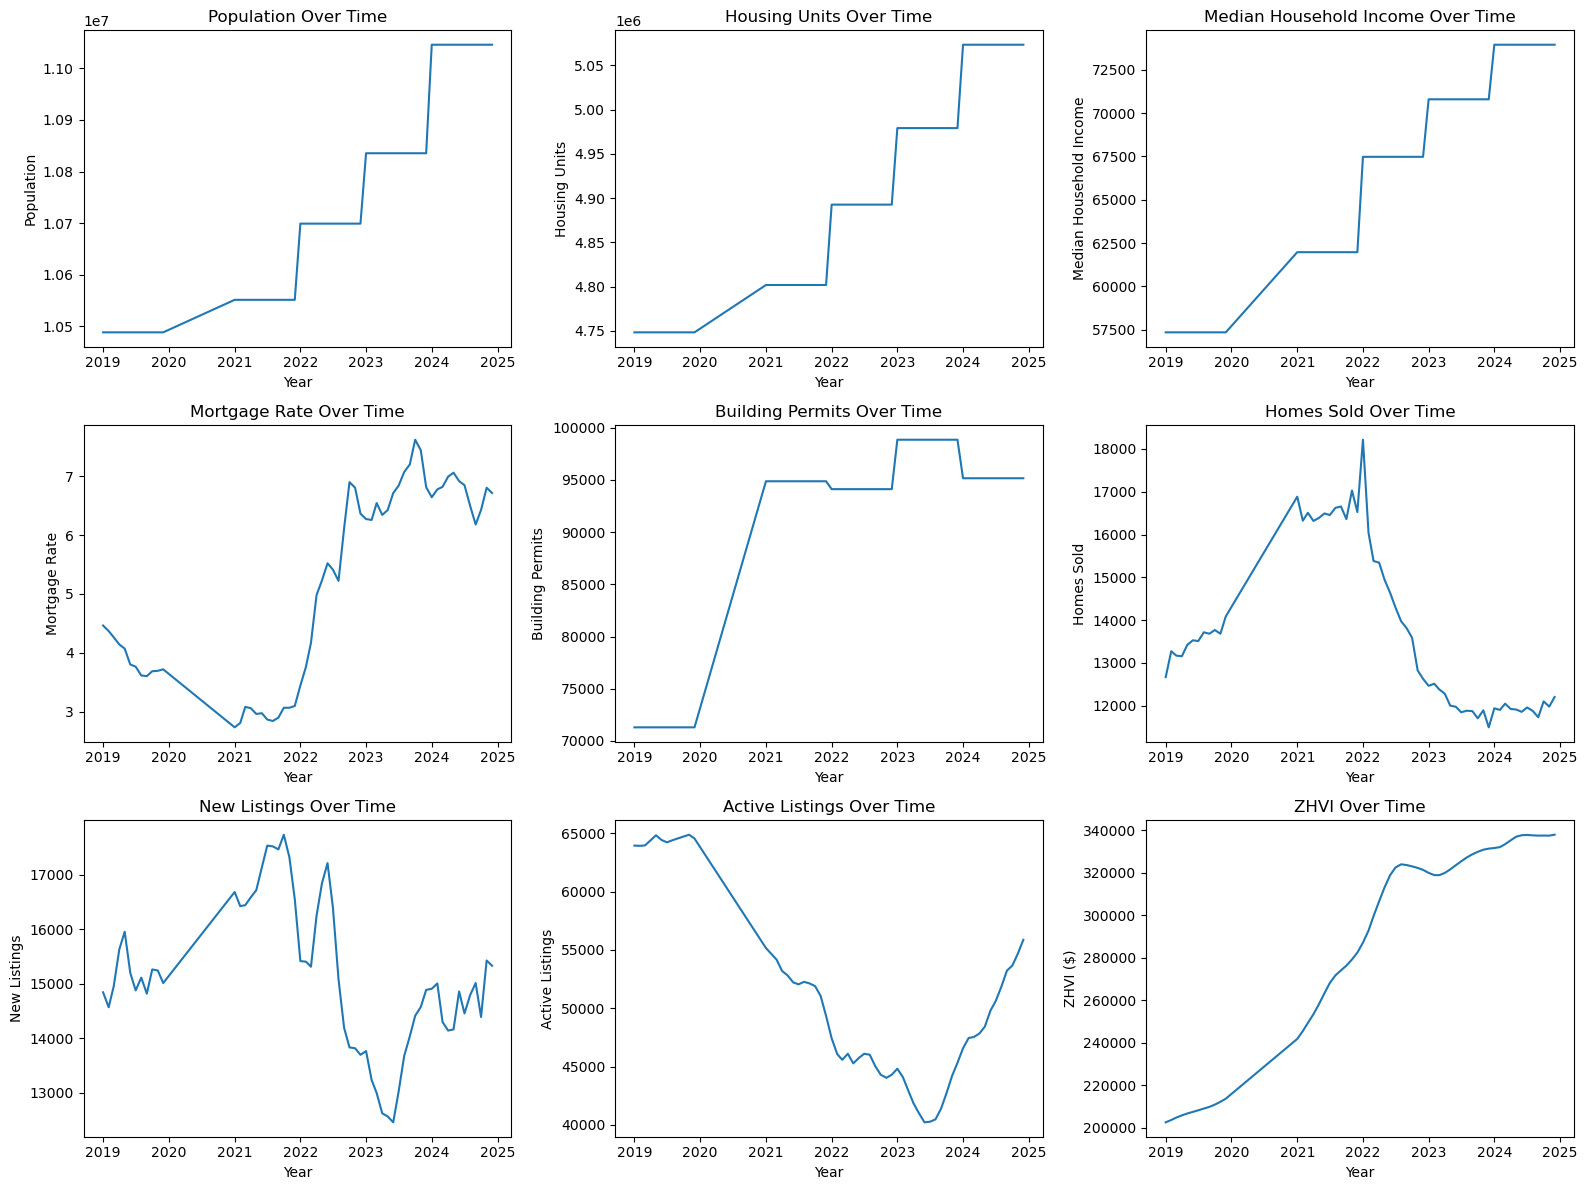

In [17]:
# Keep only data from 2019 onward
housing_2019 = housing_df[housing_df["Month"].dt.year >= 2019].copy()
recent_2019 = recent_market_df[recent_market_df["Month"].dt.year >= 2019].copy()

# Create the 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

# Original variables from housing_df
for ax, feature in zip(axes.flat, long_features):
    ax.plot(housing_2019["Month"].dt.to_timestamp(), housing_2019[feature])
    ax.set_xlabel("Year")
    ax.set_ylabel(feature.replace("_", " "))
    ax.set_title(f"{feature.replace('_', ' ')} Over Time")

# Redfin variables
redfin_features = ["Homes_Sold", "New_Listings", "Active_Listings"]

for ax, feature in zip(axes.flat[len(long_features):], redfin_features):
    ax.plot(recent_2019["Month"].dt.to_timestamp(), recent_2019[feature])
    ax.set_xlabel("Year")
    ax.set_ylabel(feature.replace("_", " "))
    ax.set_title(f"{feature.replace('_', ' ')} Over Time")

# Add ZHVI
ax = axes.flat[len(long_features) + len(redfin_features)]

ax.plot(housing_2019["Month"].dt.to_timestamp(), housing_2019["ZHVI"])
ax.set_xlabel("Year")
ax.set_ylabel("ZHVI ($)")
ax.set_title("ZHVI Over Time")

plt.tight_layout()
plt.savefig("recent_market_trends_2019_onward.png", dpi = 300, bbox_inches = "tight")
plt.show()

# Creates line graphs using only data from 2019 onward

In [18]:
# Make copies of the datasets
housing_data = housing_2019.copy()
redfin_data = recent_2019.copy()

# Add the year
housing_data["Year"] = housing_data["Month"].dt.year
redfin_data["Year"] = redfin_data["Month"].dt.year

# Calculate annual values
annual_housing = (housing_data.groupby("Year").agg({
        "ZHVI": "mean",
        "Population": "mean",
        "Housing_Units": "mean",
        "Median_Household_Income": "mean",
        "Mortgage_Rate": "mean",
        "Building_Permits": "sum"}).reset_index())

annual_redfin = (redfin_data.groupby("Year").agg({
        "Homes_Sold": "sum",
        "New_Listings": "sum",
        "Active_Listings": "mean"}).reset_index())

# Combine the two datasets
annual_data = annual_housing.merge(annual_redfin, on = "Year", how = "outer")

# Variables that should use year-over-year rate of change
rate_features = [
    "ZHVI",
    "Population",
    "Housing_Units",
    "Median_Household_Income",
    "Mortgage_Rate",
    "Active_Listings"]

# Calculate the rate of change
for feature in rate_features:
    annual_data[f"{feature}_Change_%"] = (annual_data[feature].pct_change() * 100)

# Keep only the rate-of-change columns and annual totals
annual_change = annual_data[[
        "Year",
        "ZHVI_Change_%",
        "Population_Change_%",
        "Housing_Units_Change_%",
        "Median_Household_Income_Change_%",
        "Mortgage_Rate_Change_%",
        "Building_Permits",
        "Homes_Sold",
        "New_Listings",
        "Active_Listings_Change_%"]]

# Round the percentage changes
annual_change = annual_change.round(2)

# Display the final table
annual_change

,Year,ZHVI_Change_%,Population_Change_%,Housing_Units_Change_%,Median_Household_Income_Change_%,Mortgage_Rate_Change_%,Building_Permits,Homes_Sold,New_Listings,Active_Listings_Change_%
0,2019,NaN,NaN,NaN,NaN,NaN,855684,161656.0,181500.0,NaN
1,2021,26.78,0.60,1.13,8.08,-24.86,1138488,198552.0,204135.0,-18.36
2,2022,18.69,1.40,1.89,8.89,80.24,1129416,175671.0,183481.0,-13.46
3,2023,3.76,1.28,1.77,4.92,27.55,1186236,144306.0,162275.0,-6.70
4,2024,3.51,1.94,1.89,4.45,-1.06,1141956,143427.0,176808.0,19.27


In [19]:
# Create the next-year ZHVI target
target_zhvi = zillow_nc[["Month", "ZHVI"]].copy() # copies historical Zillow data
target_zhvi["Feature_Month"] = target_zhvi["Month"] - 12 # moves the target back one year
target_zhvi = target_zhvi.rename(columns = {"ZHVI": "Target_ZHVI"}) # renames the target

# Match each feature month with the following year's ZHVI
model_df = recent_market_df.merge(target_zhvi[["Feature_Month", "Target_ZHVI"]], left_on = "Month", right_on = "Feature_Month", how = "left")
model_df = model_df.drop(columns = "Feature_Month") # removes the duplicate date column

# Use the current feature-month ZHVI as the same-month value from the previous year
model_df["ZHVI_Lag_12"] = model_df["ZHVI"]

# Add month seasonality so the model can learn yearly patterns
model_df["Month_Num"] = model_df["Month"].dt.month
model_df["Month_Sin"] = np.sin(2 * np.pi * model_df["Month_Num"] / 12)
model_df["Month_Cos"] = np.cos(2 * np.pi * model_df["Month_Num"] / 12)

# Features used for the next-year forecast
forecast_features = recent_features + ["ZHVI_Lag_12", "Month_Sin", "Month_Cos"]

# Use 2019, 2021, 2022, and 2023 as training years
train_data = model_df[model_df["Year"].isin([2019, 2021, 2022, 2023])].dropna(subset = forecast_features + ["Target_ZHVI"]).copy()

# Use 2024 as the held-out feature year
test_data = model_df[model_df["Year"] == 2024].dropna(subset = forecast_features).copy()

# Store the training features and target
X_train = train_data[forecast_features]
y_train = train_data["Target_ZHVI"]

# Store the 2024 test features
X_test = test_data[forecast_features]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training feature years:", sorted(train_data["Year"].unique()))
print("Testing feature year:", sorted(test_data["Year"].unique()))


Training rows: 48
Testing rows: 12
Training feature years: [np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)]
Testing feature year: [np.int64(2024)]


In [20]:
# Create a Linear Regression model with median imputation
linear_model = Pipeline([("imputer", SimpleImputer(strategy = "median")), ("linear", LinearRegression())])

# Train the Linear Regression model
linear_model.fit(X_train, y_train)

# Create a Random Forest for comparison
rf_model = Pipeline([("imputer", SimpleImputer(strategy = "median")),("rf", RandomForestRegressor(n_estimators = 300, max_depth = 5, min_samples_leaf = 2, random_state = 42))])

# Train the Random Forest
rf_model.fit(X_train, y_train)

# Predict 2025 ZHVI using the 2024 features
linear_test_pred = linear_model.predict(X_test)
rf_test_pred = rf_model.predict(X_test)


In [21]:
# Calculate training performance
linear_train_pred = linear_model.predict(X_train)
rf_train_pred = rf_model.predict(X_train)

training_metrics = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [np.sqrt(mean_squared_error(y_train, linear_train_pred)), np.sqrt(mean_squared_error(y_train, rf_train_pred))],
    "MAE": [mean_absolute_error(y_train, linear_train_pred), mean_absolute_error(y_train, rf_train_pred)],
    "R2": [r2_score(y_train, linear_train_pred), r2_score(y_train, rf_train_pred)]})

display(training_metrics)


,Model,RMSE,MAE,R2
0,Linear Regression,3533.403381,2685.566639,0.993839
1,Random Forest,2098.981684,1086.971183,0.997826


In [22]:
# Create the 2025 forecast table
forecast_2025_table = pd.DataFrame({
    "2024 Feature Month": test_data["Month"].astype(str),
    "2024 Actual ZHVI": test_data["ZHVI"].values,
    "Linear Regression Predicted 2025 ZHVI": linear_test_pred,
    "Random Forest Predicted 2025 ZHVI": rf_test_pred})

display(forecast_2025_table)


,2024 Feature Month,2024 Actual ZHVI,Linear Regression Predicted 2025 ZHVI,Random Forest Predicted 2025 ZHVI
48,2024-01,331694.211454,363479.621520,334169.951036
49,2024-02,332115.871636,362170.195461,332840.818965
50,2024-03,333491.464526,364354.480581,334593.336773
51,2024-04,335310.786689,365104.647932,334805.400538
52,2024-05,337003.295767,366205.424314,334846.600837
53,2024-06,337692.546646,365730.411321,334785.119137
54,2024-07,337843.602198,367111.265434,335227.069090
55,2024-08,337637.705627,367086.664114,335091.611008
56,2024-09,337521.928506,366692.599015,323502.126000
57,2024-10,337539.608817,367575.604619,322051.919070


In [23]:
# Load the actual 2025 Zillow values
zillow_2025 = zillow_raw[zillow_raw["RegionName"] == "North Carolina"].copy()
date_columns_2025 = pd.date_range(start = "2025-01-31", end = "2025-12-31", freq = "ME").strftime("%Y-%m-%d").tolist()
zillow_2025 = zillow_2025[["RegionName"] + date_columns_2025].melt(id_vars = "RegionName", var_name = "Month",value_name = "ZHVI")
zillow_2025["Month"] = pd.to_datetime(zillow_2025["Month"]).dt.to_period("M")
zillow_2025 = zillow_2025.sort_values("Month").reset_index(drop = True)

# Match each 2025 target to its 2024 feature month
test_target = zillow_2025[["Month", "ZHVI"]].copy()
test_target = test_target.rename(columns = {"ZHVI": "Actual_2025_ZHVI"})
test_target["Feature_Month"] = test_target["Month"] - 12
target_lookup = test_target.set_index("Feature_Month")["Actual_2025_ZHVI"] # Match actual 2025 values to the 2024 test months
test_data["Actual_2025_ZHVI"] = test_data["Month"].map(target_lookup)
y_test = test_data["Actual_2025_ZHVI"] # Store the actual 2025 ZHVI

# Use the same month from 2024 as the baseline
baseline_pred = test_data["ZHVI"].values
print("2025 target rows:", y_test.notna().sum())


2025 target rows: 12


In [24]:
# Create the final 2025 prediction table
test_predictions = pd.DataFrame({
    "2024 Feature Month": test_data["Month"].astype(str),
    "2024 Actual ZHVI": test_data["ZHVI"].values,
    "Actual 2025 ZHVI": y_test.values,
    "Linear Regression Predicted 2025 ZHVI": linear_test_pred,
    "Random Forest Predicted 2025 ZHVI": rf_test_pred})

display(test_predictions)


,2024 Feature Month,2024 Actual ZHVI,Actual 2025 ZHVI,Linear Regression Predicted 2025 ZHVI,Random Forest Predicted 2025 ZHVI
48,2024-01,331694.211454,338393.997454,363479.621520,334169.951036
49,2024-02,332115.871636,338706.794035,362170.195461,332840.818965
50,2024-03,333491.464526,338229.930519,364354.480581,334593.336773
51,2024-04,335310.786689,337404.318773,365104.647932,334805.400538
52,2024-05,337003.295767,336605.823839,366205.424314,334846.600837
53,2024-06,337692.546646,335811.620942,365730.411321,334785.119137
54,2024-07,337843.602198,335262.580245,367111.265434,335227.069090
55,2024-08,337637.705627,334866.458398,367086.664114,335091.611008
56,2024-09,337521.928506,335021.890708,366692.599015,323502.126000
57,2024-10,337539.608817,335295.952774,367575.604619,322051.919070


In [25]:
# Calculate test performance
test_metrics = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "RMSE": [np.sqrt(mean_squared_error(y_test, baseline_pred)), np.sqrt(mean_squared_error(y_test, linear_test_pred)), np.sqrt(mean_squared_error(y_test, rf_test_pred))],
    "MAE": [mean_absolute_error(y_test, baseline_pred), mean_absolute_error(y_test, linear_test_pred), mean_absolute_error(y_test, rf_test_pred)],
    "R2": [r2_score(y_test, baseline_pred), r2_score(y_test, linear_test_pred), r2_score(y_test, rf_test_pred)]})

display(test_metrics)


,Model,RMSE,MAE,R2
0,Baseline,3570.256036,3050.410673,-5.994729
1,Linear Regression,28935.432722,28797.198449,-458.443533
2,Random Forest,9244.452228,6660.387978,-45.895864


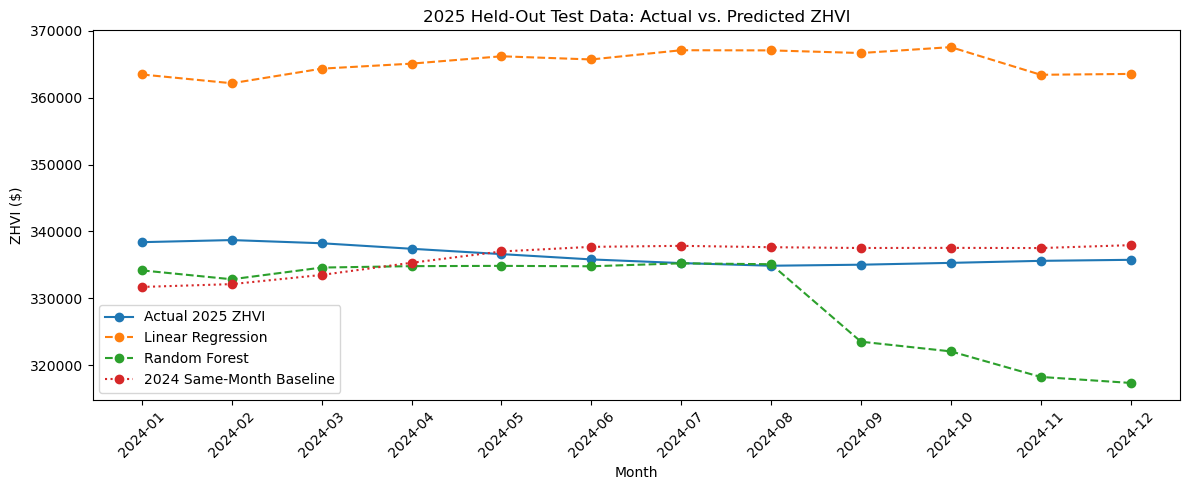

In [26]:
# Plot the 2025 held-out test results
plt.figure(figsize = (12, 5))

plt.plot(test_data["Month"].astype(str), y_test, marker = "o", label = "Actual 2025 ZHVI")
plt.plot(test_data["Month"].astype(str), linear_test_pred, marker = "o", linestyle = "--", label = "Linear Regression")
plt.plot(test_data["Month"].astype(str), rf_test_pred, marker = "o", linestyle = "--", label = "Random Forest")
plt.plot(test_data["Month"].astype(str), baseline_pred, marker = "o", linestyle = ":", label = "2024 Same-Month Baseline")

plt.xlabel("Month")
plt.ylabel("ZHVI ($)")
plt.title("2025 Held-Out Test Data: Actual vs. Predicted ZHVI")
plt.xticks(rotation = 45)
plt.legend()
plt.tight_layout()
plt.savefig("2025_actual_vs_predicted_ZHVI.png", dpi = 300, bbox_inches = "tight")
plt.show()


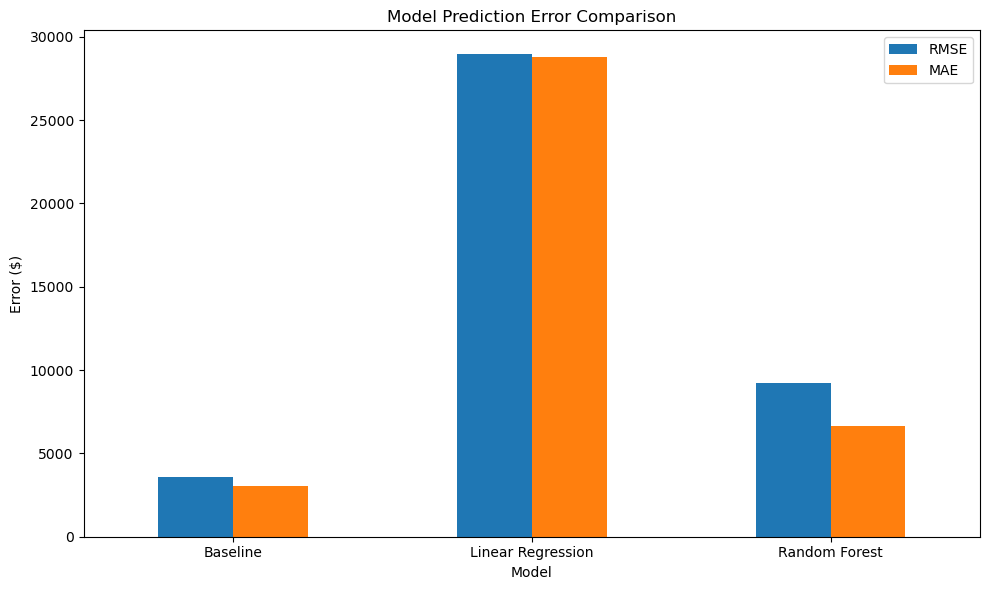

In [27]:
test_metrics.plot(x = "Model", y = ["RMSE", "MAE"], kind = "bar", figsize = (10, 6))

plt.ylabel("Error ($)")
plt.title("Model Prediction Error Comparison")
plt.xticks(rotation = 0)

plt.tight_layout()
plt.savefig("model_prediction_error_comparison.png", dpi = 300, bbox_inches = "tight")
plt.show()

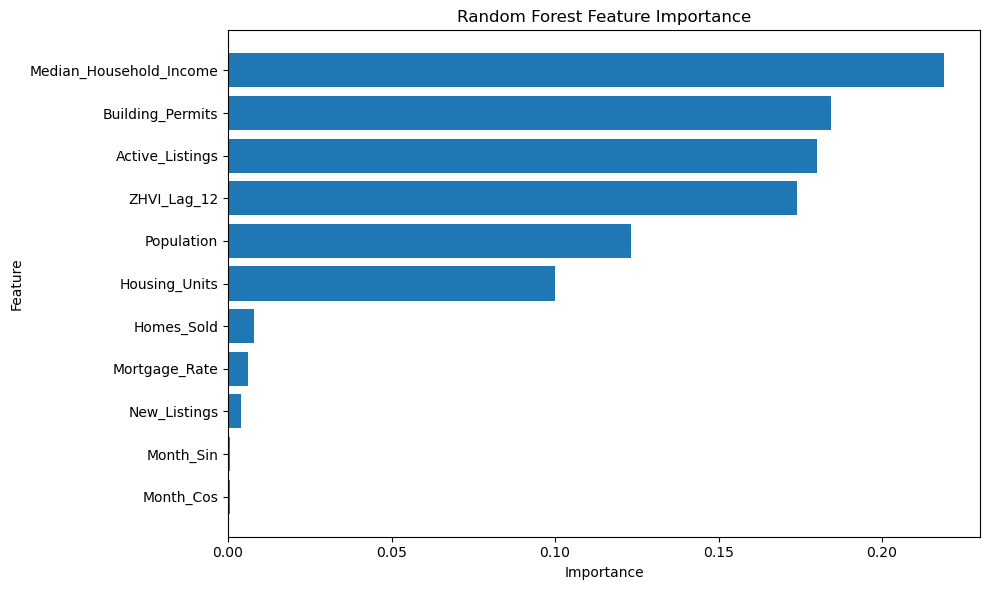

In [28]:
# Get Random Forest feature importance
importance = pd.DataFrame({
    "Feature": forecast_features,
    "Importance": rf_model.named_steps["rf"].feature_importances_})

importance = importance.sort_values("Importance", ascending = True)

plt.figure(figsize = (10, 6))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()
